In [1]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


In [2]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)
importlib.reload(vf)

<module 'voxel_functions' from '/mnt/data2/Justice/OR_learning/utils/voxel_functions.py'>

### CNN 

#### Prepare ORs voxels 

In [3]:
# Load in ESM embeddings
res_esm = np.load('/mnt/data2/Justice/OR_learning/files/ESM/residue_embeddings.npy', 
                  allow_pickle=True)
OR_label = np.load('/mnt/data2/Justice/OR_learning/files/ESM/esm_OR_order.npy', 
                 allow_pickle=True)

In [4]:
"""
Reduces ESM feature from 1280 -> 64 

The reduction is done globally, then each ESM is then split back into len of original ORs. 
"""
from sklearn.decomposition import TruncatedSVD

# esm_embeddings: list of arrays (shape = [L, 1280])
all_residues = np.vstack(res_esm)  # shape = [total_residues, 1280]

svd = TruncatedSVD(n_components=64, random_state=42)
res_esm_reduced = svd.fit_transform(all_residues)

print(f'SVD explained variance: {np.sum(svd.explained_variance_ratio_)}')

# Track the number of residues (length) in each OR
lengths = [arr.shape[0] for arr in res_esm]
# Use np.split to break the reduced array back into original groups
res_esm_reduced = np.split(res_esm_reduced, np.cumsum(lengths)[:-1])

# Re-Join OR label and ESM 
OR_esm = {str(_OR): res_esm_reduced[i] for i, _OR in enumerate(OR_label)}

SVD explained variance: 0.5381844639778137


In [3]:
Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/dict_Cbc_cav_coords.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/dict_Cbc_res_coords.pkl')

In [6]:
"""
Voxelize cavity and residue coordinates into voxel format
"""

from tqdm import tqdm 

voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                      residue_coords = Cbc_res_coords,
                                      resolution = 1, 
                                      encode_method='esm', 
                                      OR_esm = OR_esm, 
                                      esm_order = list(Cbc_cav_coords), 
                                      vdw_radius = True, 
                                      sparse_mode = False)

print(f'Grid shape: {grid_shape}')
# print(f'Grid shape: {grid_shape}, Feature size: {len(sparse_voxels[0][list(sparse_voxels[0].keys())[0]])}')


Encoding voxels via esm...
Generating voxels. . .


100%|██████████| 1057/1057 [02:07<00:00,  8.29it/s]


Grid shape: [43 41 42]


#### Prepare ligand tensors 

In [ ]:
"""
Prepare cid features 
"""

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'logFC_adj_zscore']).dropna()
# Subset for ORs in voxel ORs.  
ps6_df = ps6_df[ps6_df.DL_OR.isin(Cbc_res_coords.keys())]

import pubchempy as pcp
from tqdm import tqdm

def cid_to_smiles(cid):
    try:
        # compound = pcp.Compound.from_cid(cid) # Broken . . . Still waiting for fix 
        # return compound.isomeric_smiles

        # Temporary fix
        pcp_compound = pcp.get_compounds(cid, "cid")
        pcp_values = [i for i in pcp_compound[0].to_dict().get("record").get("props") if i["urn"]["label"] == "SMILES"]
        return pcp_values[1]['value']['sval'] if len(pcp_values) > 0 else None        
    except:
        return None

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

def smiles_to_ecfp4(smiles, n_bits=1028):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits))
    else:
        return None

# Generate smiles from pS6-IP cid 
unique_cids = ps6_df.cid.unique()
cid_smiles_dict = {cid: cid_to_smiles(str(cid)) for cid in tqdm(unique_cids)}

# Create fingerprint from smiles 

ligand_fp_dict = {}
for cid, smiles in tqdm(cid_smiles_dict.items()):
    if smiles:
        fp = smiles_to_ecfp4(smiles)
        if fp is not None:
            ligand_fp_dict[cid] = fp

ligand_fp_df = pd.DataFrame.from_dict(ligand_fp_dict, orient='index')
ligand_fp_df.index.name = 'cid'
pca = PCA(n_components=32)

import torch 
ligand_fp_tensor = torch.tensor(pca.fit_transform(ligand_fp_df.values), dtype=torch.float32)

print(f'PCA explained variance: {np.sum(pca.explained_variance_ratio_)}')

# SAVED ligand_fp_tensor for loading in the future 
# np.save('/mnt/data2/Justice/OR_learning/output/cid_smiles_dict.npy', cid_smiles_dict)
# torch.save(ligand_fp_tensor, '/mnt/data2/Justice/OR_learning/output/ligand_fp_tensor.pt')



In [ ]:
or_ids = list(Cbc_res_coords.keys())
# ligand_cids = list(cid_smiles_dict.keys())
# or_index_map = {or_id: i for i, or_id in enumerate(or_ids)}
# ligand_index_map = {cid: i for i, cid in enumerate(ligand_cids)}
# voxel_tensor = torch.stack(voxels)

# Set your desired target ratio
POSITIVE_WEIGHT = 0.5  

# Separate positives and zeros
positive_df = ps6_df[ps6_df['logfc_'] > 0]
negative_df = ps6_df[ps6_df['score'] == 0]

# Number of samples to take
total_samples = 1000
n_pos = int(total_samples * POSITIVE_WEIGHT)
n_neg = total_samples - n_pos

# Sample with controlled balance
sampled_positives = positive_df.sample(n=min(n_pos, len(positive_df)), random_state=0)
sampled_negatives = negative_df.sample(n=n_neg, random_state=0)
subset_df = pd.concat([sampled_positives, sampled_negatives]).sample(frac=1.0, random_state=0)

In [ ]:
sampled_positives = positive_df.sample(n=min(n_pos, len(positive_df)), random_state=42)
sampled_negatives = negative_df.sample(n=n_neg, random_state=42)

subset_df = pd.concat([sampled_positives, sampled_negatives]).sample(frac=1.0, random_state=42)


### CNN model

In [ ]:
from torch.utils.data import Dataset

class ORLigandIndexDataset(Dataset):
    def __init__(self, pairs_df, voxel_tensor, ligand_fp_tensor, or_index_map, ligand_index_map):
        self.voxel_tensor = voxel_tensor
        self.ligand_fp_tensor = ligand_fp_tensor
        self.targets = []
        self.indices = []

        for _, row in pairs_df.iterrows():
            or_id = row['DL_OR']
            cid = row['cid']

            if or_id in or_index_map and cid in ligand_index_map:
                self.indices.append((or_index_map[or_id], ligand_index_map[cid]))
                self.targets.append(row['logFC_adj_zscore'])

        self.targets = torch.tensor(self.targets, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        or_idx, ligand_idx = self.indices[idx]
        voxel = self.voxel_tensor[or_idx]           # [D, H, W, C]
        ligand = self.ligand_fp_tensor[ligand_idx]  # [F]
        target = self.targets[idx]                  # scalar
        return voxel, ligand, target
    
import torch.nn as nn
import torch.nn.functional as F

class ORLigandCNN(nn.Module):
    def __init__(self, ligand_dim, output_dim=1):
        super(ORLigandCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv3d(in_channels=65, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2),  # down to ~[20,21,32]
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2),  # down to ~[10,10,16]
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 10 * 10 * 16 + ligand_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, voxel, ligand):
        voxel = voxel.permute(0, 4, 1, 2, 3)  # to [B, C, D, H, W]
        voxel_feat = self.cnn(voxel)
        combined = torch.cat([voxel_feat, ligand], dim=1)
        return self.fc(combined)

In [ ]:
# voxel_tensor.shape: [N_or, D, H, W, C]
# ligand_fp_tensor.shape: [N_ligand, F]

# Map IDs to indices
or_ids = list(Cbc_res_coords.keys())
ligand_cids = list(cid_smiles_dict.keys())

or_index_map = {or_id: i for i, or_id in enumerate(or_ids)}
ligand_index_map = {cid: i for i, cid in enumerate(ligand_cids)}

# Train/test split of pair dataframe
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(ps6_df, test_size=0.2, random_state=42)

# Create datasets
voxel_tensor = torch.stack(voxels)

train_dataset = ORLigandIndexDataset(train_df, voxel_tensor, ligand_fp_tensor, or_index_map, ligand_index_map)
test_dataset = ORLigandIndexDataset(test_df, voxel_tensor, ligand_fp_tensor, or_index_map, ligand_index_map)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

model = ORLigandCNN(ligand_dim=ligand_fp_tensor.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training
for epoch in range(20):
    model.train()
    total_loss = 0
    for vox, lig, y in train_loader:
        pred = model(vox, lig)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss / len(train_loader):.4f}")

### Evaluating hyperparameters

In [3]:
import numpy as np
import os

def is_val_loss_trending_down(val_losses, slope_threshold=-0.001):
    """Return True if val_loss has a downward slope over epochs."""
    epochs = np.arange(len(val_losses))
    slope = np.polyfit(epochs, val_losses, 1)[0]
    return slope < slope_threshold

def rank_models_across_runs(base_dir, slope_threshold = -0.001, min_best_epoch=2, auc_threshold=0.6, alpha=0.2):
    ranked_models = []

    for run_name in sorted(os.listdir(base_dir)):
        run_path = os.path.join(base_dir, run_name)
        if not os.path.isdir(run_path):
            continue

        try:
            val_aucs = np.load(os.path.join(run_path, "val_aucs.npy"))
            val_losses = np.load(os.path.join(run_path, "val_losses.npy"))
            train_losses = np.load(os.path.join(run_path, "train_losses.npy"))
        except FileNotFoundError:
            print(f"Skipping {run_name}: missing file.")
            continue

        # Skip if val_loss not trending down
        epochs = np.arange(len(val_losses))
        slope = np.polyfit(epochs, val_losses, 1)[0]
        if not slope < slope_threshold:
            continue

        best_epoch = int(np.argmax(val_aucs))
        best_auc = val_aucs[best_epoch]
        best_val_loss = val_losses[best_epoch]
        train_loss = train_losses[best_epoch]

        # Skip if best epoch is too early
        if best_epoch < min_best_epoch:
            continue

        # Optional: skip weak AUCs
        if best_auc < auc_threshold:
            continue

        # Composite score: balance AUC with overfitting penalty
        # score = best_auc - alpha * (best_val_loss - train_loss)
        score = best_auc - alpha * (slope)

        ranked_models.append({
            "run_name": run_name,
            "score": score,
            "best_auc": best_auc,
            "best_val_loss": best_val_loss,
            "val_loss_slope": slope, 
            "train_loss": train_loss,
            "best_epoch": best_epoch
        })

    # Sort by score descending
    ranked_models = sorted(ranked_models, key=lambda x: x["score"], reverse=True)
    return ranked_models

In [4]:
base_dir = '/mnt/data2/Justice/OR_learning/output/cnn_spatialAA_binary/'
results = rank_models_across_runs(base_dir, slope_threshold=-1e-5, alpha=0.1, auc_threshold=0.60)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Skipping 20250721_170040_ptAVG_lr0.01_bs16_hd128_ks1_nl2_do0.3: missing file.
Skipping test_params: missing file.
Skipping test_params_out: missing file.
Rank 1 : 20250721_003210_ptMAX_lr0.005_bs32_hd128_ks1_nl4_do0.7       | AUC: 0.8019 | ValLoss: 0.583 | ValLossSlope: -0.0006889 | Epoch: 45
Rank 2 : 20250720_163904_ptAVG_lr0.0005_bs32_hd128_ks1_nl4_do0.5      | AUC: 0.7489 | ValLoss: 0.6006 | ValLossSlope: -0.001818 | Epoch: 24
Rank 3 : 20250721_003444_ptAVG_lr0.0005_bs32_hd512_ks1_nl4_do0.0      | AUC: 0.7440 | ValLoss: 0.6716 | ValLossSlope: -0.0006871 | Epoch: 46
Rank 4 : 20250720_191032_ptAVG_lr0.0005_bs32_hd64_ks1_nl4_do0.0       | AUC: 0.7308 | ValLoss: 0.6424 | ValLossSlope: -0.0009472 | Epoch: 55
Rank 5 : 20250720_173254_ptAVG_lr0.0001_bs16_hd1024_ks1_nl2_do0.3     | AUC: 0.7192 | ValLoss: 0.6699 | ValLossSlope: -0.000383 | Epoch: 38
Rank 6 : 20250721_113046_ptMAX_lr0.01_bs4_hd1024_ks5_nl2_do0.5        | AUC: 0.7174 | ValLoss: 0.652 | ValLossSlope: -0.004501 | Epoch: 20
Rank 

In [ ]:
""" 
Copy param.json to test_param to run longer 
"""

import shutil

for i, r in enumerate(results[:10]): 
    shutil.copy(os.path.join(base_dir, r['run_name'], 'params.json'), 
                os.path.join(base_dir, 'test_params', f'{r['run_name']}_params.json'))
    
    
# Manually include cases 
add_run_id = ['20250720_213430_ptAVG_lr0.0001_bs8_hd256_ks1_nl4_do0.7']

for i, r in enumerate(add_run_id): 
    shutil.copy(os.path.join(base_dir, r, 'params.json'), 
                os.path.join(base_dir, 'test_params', f'{r}_params.json'))
    
    

In [18]:
base_dir = '/mnt/data2/Justice/OR_learning/output/cnn_spatialAA_binary/'
results = rank_models_across_runs(base_dir, slope_threshold=-1e-5, alpha=0.1, auc_threshold=0.60)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Skipping 20250721_170040_ptAVG_lr0.01_bs16_hd128_ks1_nl2_do0.3: missing file.
Skipping test_params: missing file.
Skipping test_params_out: missing file.
Rank 1 : 20250721_003210_ptMAX_lr0.005_bs32_hd128_ks1_nl4_do0.7       | AUC: 0.8019 | ValLoss: 0.583 | ValLossSlope: -0.0006889 | Epoch: 45
Rank 2 : 20250720_163904_ptAVG_lr0.0005_bs32_hd128_ks1_nl4_do0.5      | AUC: 0.7489 | ValLoss: 0.6006 | ValLossSlope: -0.001818 | Epoch: 24
Rank 3 : 20250721_003444_ptAVG_lr0.0005_bs32_hd512_ks1_nl4_do0.0      | AUC: 0.7440 | ValLoss: 0.6716 | ValLossSlope: -0.0006871 | Epoch: 46
Rank 4 : 20250720_191032_ptAVG_lr0.0005_bs32_hd64_ks1_nl4_do0.0       | AUC: 0.7308 | ValLoss: 0.6424 | ValLossSlope: -0.0009472 | Epoch: 55
Rank 5 : 20250720_173254_ptAVG_lr0.0001_bs16_hd1024_ks1_nl2_do0.3     | AUC: 0.7192 | ValLoss: 0.6699 | ValLossSlope: -0.000383 | Epoch: 38
Rank 6 : 20250721_113046_ptMAX_lr0.01_bs4_hd1024_ks5_nl2_do0.5        | AUC: 0.7174 | ValLoss: 0.652 | ValLossSlope: -0.004501 | Epoch: 20
Rank 

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plot_result = results[:12]

fig_roc, axes_roc = plt.subplots(figsize = (6,6))


for i, r in enumerate(plot_result):
    
    # Plot roc
    val_labels_flat = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs_flat  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    val_auc = roc_auc_score(val_labels_flat, val_probs_flat)
    fpr, tpr, _ = roc_curve(val_labels_flat, val_probs_flat)
    
    axes_roc.plot(fpr, tpr, label=f"AUC = {val_auc:.2f}", c='#D3D3D3')
    
axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



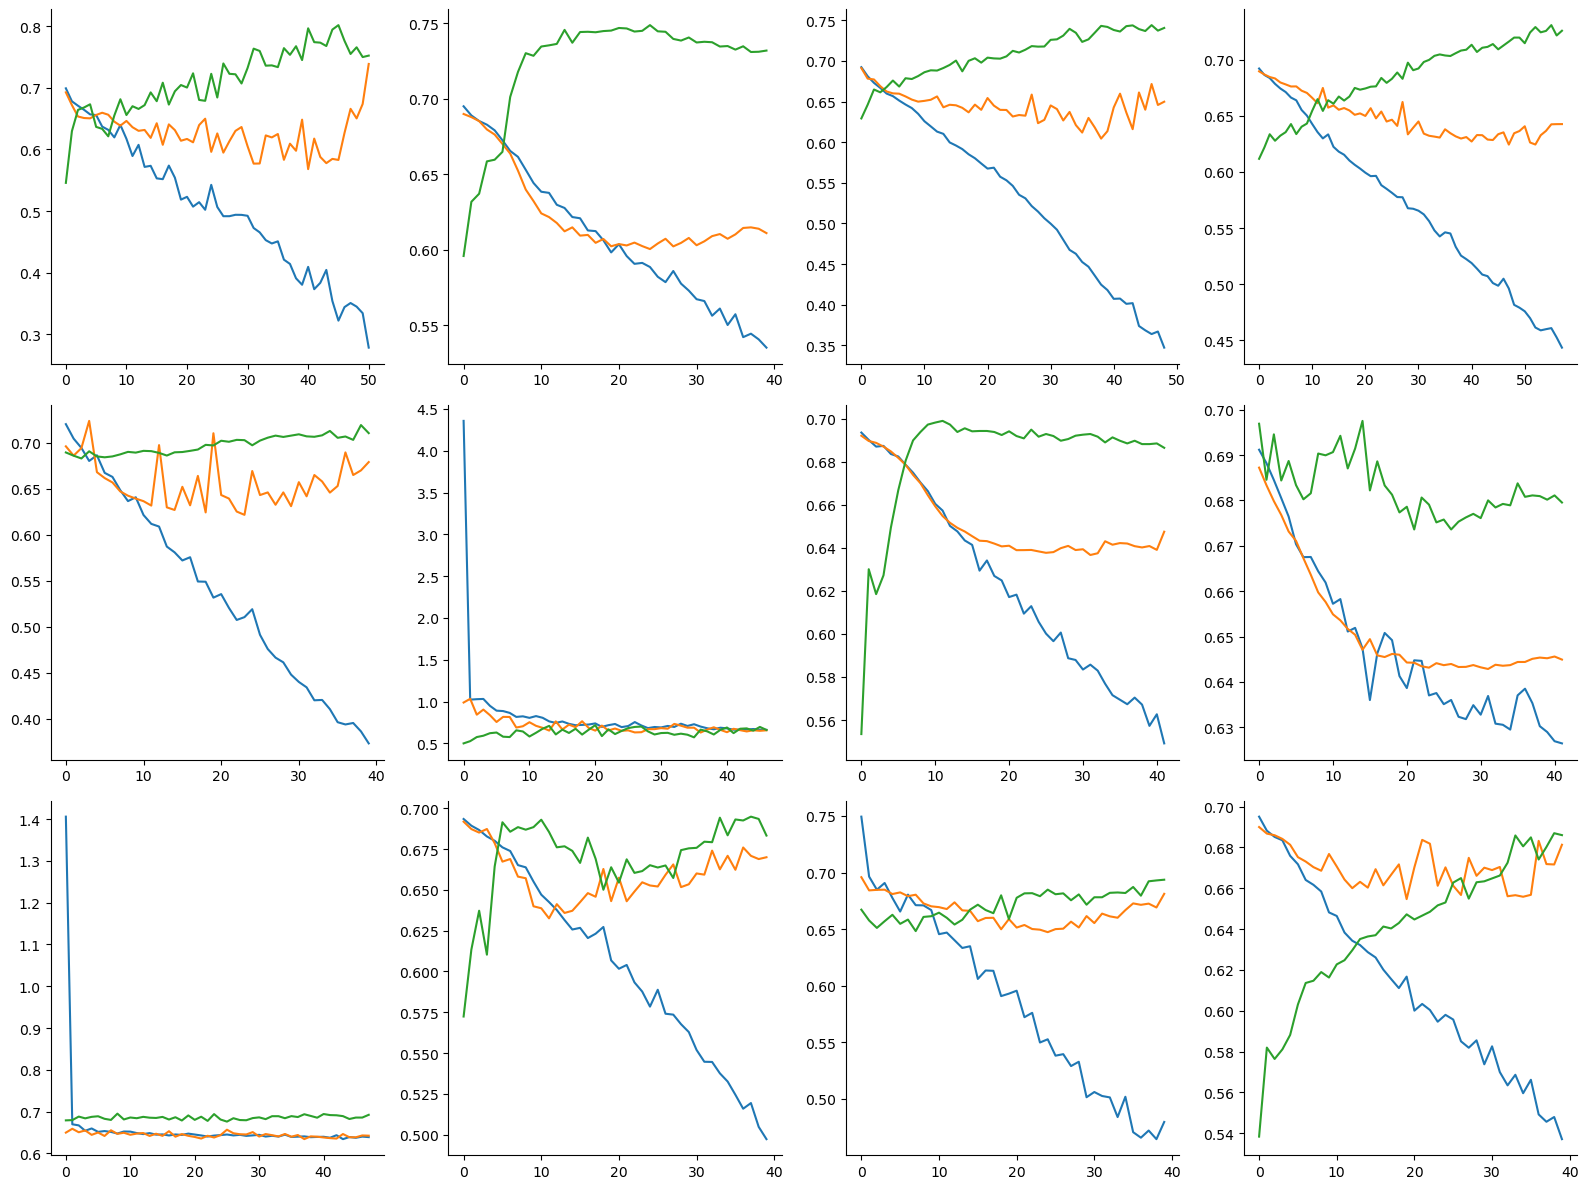

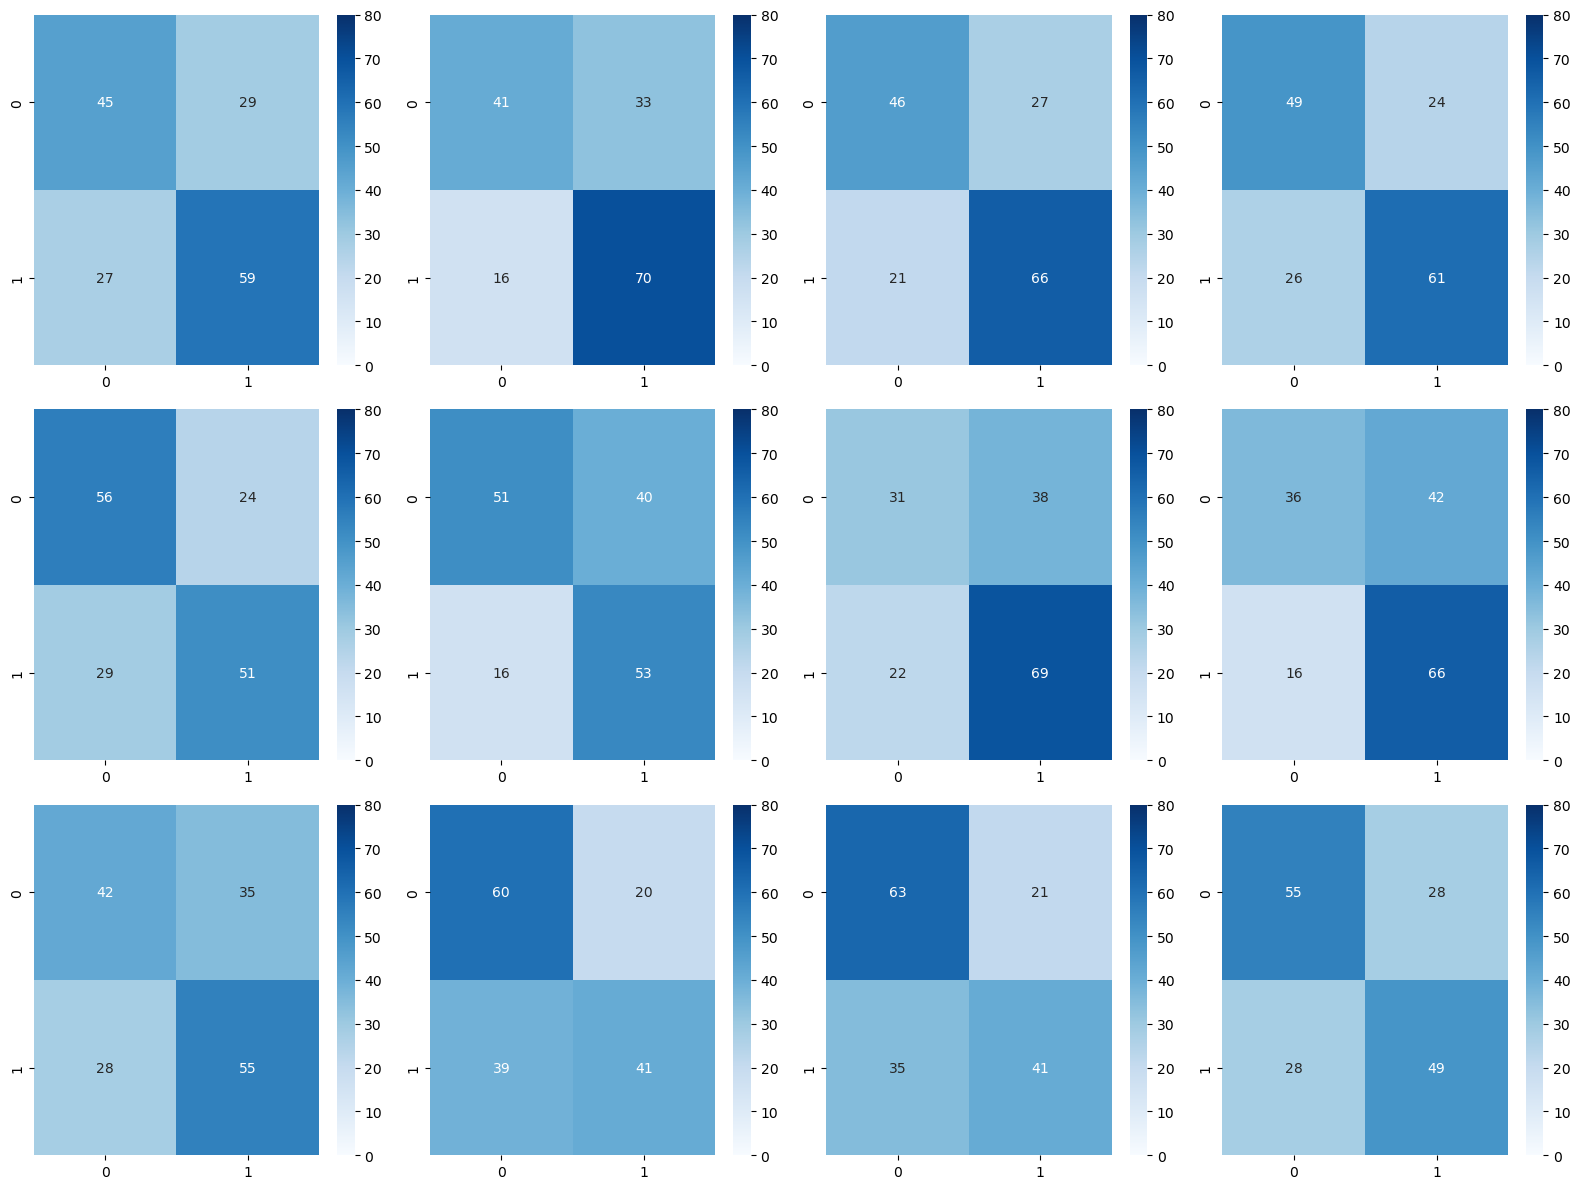

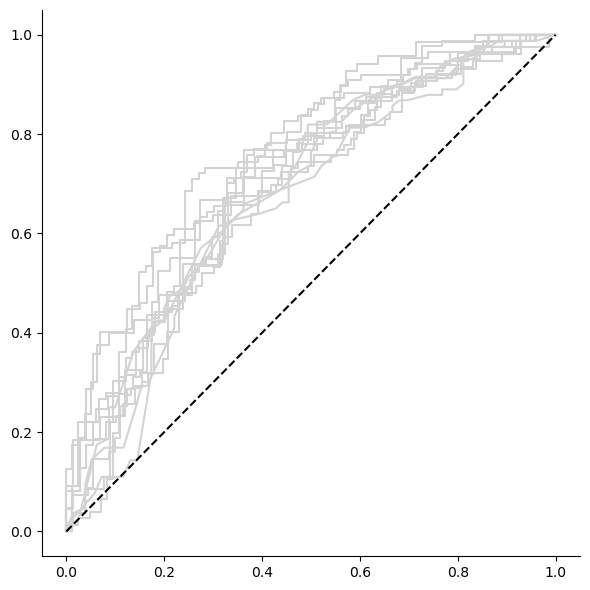

In [14]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plot_result = results[:12]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4 
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_conf, axes_conf = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_conf = np.array(axes_conf).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))


for i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_aucs.npy'))
    
    ax1 = axes_curve[i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    # Plot matrices
    conf = confusion_matrix(val_labels_flat, (val_probs_flat > 0.5).astype(np.float32))

    ax2 = axes_conf[i]
    sns.heatmap(conf, annot=True, 
                      fmt='d', 
                      cmap='Blues',
                      vmin=0, vmax=80, 
                      ax = ax2)
    
    # Plot roc
    val_labels_flat = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs_flat  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    val_auc = roc_auc_score(val_labels_flat, val_probs_flat)
    fpr, tpr, _ = roc_curve(val_labels_flat, val_probs_flat)
    
    # ax2 = axes_roc[i]
    # axes_roc.plot(fpr, tpr, label=f"AUC = {val_auc:.2f}")
    # axes_roc.plot([0, 1], [0, 1], 'k--')
    # axes_roc.legend()
    
    axes_roc.plot(fpr, tpr, label=f"AUC = {val_auc:.2f}", c='#D3D3D3')
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

fig_conf = pf.plt_clean_axes(fig_conf)
fig_conf.tight_layout()
fig_conf.show()

axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



<Axes: >

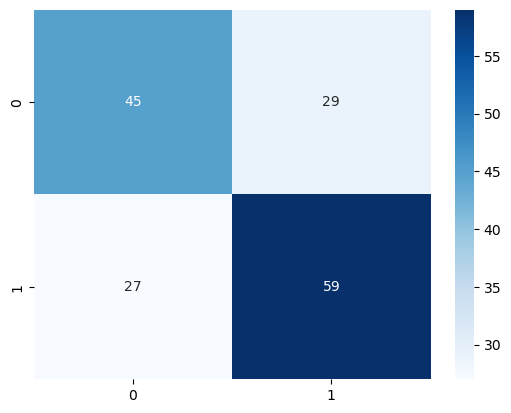

In [45]:
import seaborn as sns 
conf = confusion_matrix(val_labels_flat, (val_probs_flat > 0.5).astype(np.float32))
plt.figure()
sns.heatmap(conf, annot=True, 
            fmt='d', 
            cmap='Blues')



### 3Dpooled SVD, spatial ESM (xgBoost, Ridge...)

In [ ]:
# truncatedSVD dimensions via spatial encoding res 
svd_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/Cbc_esm_sparse_voxels/Cbc_esm_SparseVox_SVD.csv', index_col = 0)

In [86]:
# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'logFC_adj_zscore']).dropna()
# Subset for ORs in svd_df 
ps6_df = ps6_df[ps6_df.DL_OR.isin(svd_df.index)]

In [ ]:
# Prepare cid features 

import pubchempy as pcp
from tqdm import tqdm

def cid_to_smiles(cid):
    try:
        compound = pcp.Compound.from_cid(cid)
        return compound.isomeric_smiles
    except:
        return None
    
unique_cids = ps6_df.cid.unique()
cid_smiles_dict = {cid: cid_to_smiles(str(cid)) for cid in tqdm(unique_cids)}

from rdkit import Chem
from rdkit.Chem import AllChem

def smiles_to_ecfp4(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits))
    else:
        return None

# Create fingerprint dataframe
ligand_fp_dict = {}
for cid, smiles in tqdm(cid_smiles_dict.items()):
    if smiles:
        fp = smiles_to_ecfp4(smiles)
        if fp is not None:
            ligand_fp_dict[cid] = fp

ligand_fp_df = pd.DataFrame.from_dict(ligand_fp_dict, orient='index')
ligand_fp_df.index.name = 'cid'

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

def smiles_to_ecfp4(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=256))
    else:
        return None

# Create fingerprint dataframe
ligand_fp_dict = {}
for cid, smiles in tqdm(cid_smiles_dict.items()):
    if smiles:
        fp = smiles_to_ecfp4(smiles)
        if fp is not None:
            ligand_fp_dict[cid] = fp

ligand_fp_df = pd.DataFrame.from_dict(ligand_fp_dict, orient='index')
ligand_fp_df.index.name = 'cid'
pca = PCA(n_components=50)
fp_reduced = pd.DataFrame(pca.fit_transform(ligand_fp_df.values), index = ligand_fp_df.index)

import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("n_components")
plt.ylabel("Cumulative Explained Variance")

In [292]:
from sklearn.preprocessing import StandardScaler

receptor_scaled = pd.DataFrame(StandardScaler().fit_transform(svd_df), index=svd_df.index, 
                               columns = [f'spatialEsmSVD_{i}' for i in range(len(svd_df.columns))])
ligand_scaled = pd.DataFrame(StandardScaler().fit_transform(fp_reduced), index=fp_reduced.index, 
                             columns = [f'ligPC_{i}' for i in range(len(fp_reduced.columns))])

In [301]:
merged = ps6_df[['DL_OR', 'cid', 'logFC_adj_zscore']].merge(receptor_scaled.reset_index(names='DL_OR'), on='DL_OR')
merged = merged.merge(ligand_scaled.reset_index(names='cid'), on='cid')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# Join OR vector to activation data
# merged = ps6_df[['DL_OR', 'cid', 'logFC_adj_zscore']].merge(svd_df.reset_index(names='DL_OR'), on='DL_OR')

# Features: columns 4 onwards (300 dims), Target: logFC_adj_zscore
X = merged.iloc[:,3:].values
y = merged['logFC_adj_zscore'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1]
lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1]

mse_list = []
pearson_list = []

for l in lambdas:
    model = Ridge(alpha=l)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r, _ = pearsonr(y_test, y_pred)

    mse_list.append(mse)
    pearson_list.append(r)


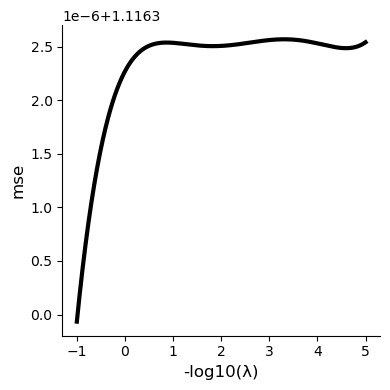

In [303]:
fig, ax = pf.plt_correlation(-np.log10(lambdas), mse_list, 
                             xlabel = '-log10(λ)', ylabel='mse', 
                             figsize=[4,4], 
                             edgecolor='black', 
                             plot_pearson_line=False, 
                             smooth_scatter_line=True, 
                             edgesize = 3, opacity = 1, 
                             poly_degree=5, 
                             plot_style = 'scatter_line'
                            #  pearson_fontsize=10, opacity= 0.1
                            #  linewidth = 3
                            #  plot_style='hist2d', bins = 100
                             )

In [221]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# === Load your data ===
# Assume: 
# - X_features is your receptor input embedding (index = receptor names)
# - df_response is your target (with receptor names in 'DL_OR')

# Join OR vector to activation data
merged = ps6_df[['DL_OR', 'cid', 'logFC_adj_zscore']].merge(svd_df.reset_index(names='DL_OR'), on='DL_OR')

# Features: columns 4 onwards (300 dims), Target: logFC_adj_zscore
X = merged.iloc[:,3:].values
y = merged['logFC_adj_zscore'].values

# === Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# === XGBoost model ===
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# === Evaluate ===
mse = mean_squared_error(y_test, y_pred)
r, _ = pearsonr(y_test, y_pred)
print(f"XGBoost → MSE: {mse:.4f}, Pearson r: {r:.4f}")

# === Shuffle baseline ===
np.random.seed(0)
y_shuffled = np.random.permutation(y)  # Shuffle labels

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_shuffled, test_size=0.2, random_state=0)

model_shuffled = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model_shuffled.fit(X_train_s, y_train_s)
y_pred_shuffled = model_shuffled.predict(X_test_s)

mse_s = mean_squared_error(y_test_s, y_pred_shuffled)
r_s, _ = pearsonr(y_test_s, y_pred_shuffled)
print(f"Shuffled → MSE: {mse_s:.4f}, Pearson r: {r_s:.4f}")

XGBoost → MSE: 1.0203, Pearson r: 0.1065
Shuffled → MSE: 1.2834, Pearson r: -0.0010


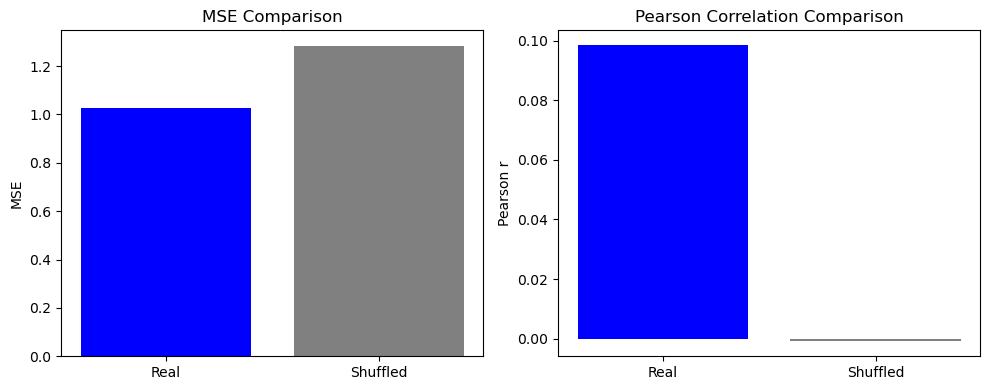

In [225]:
# === Plot comparison ===
labels = ['Real', 'Shuffled']
mse_vals = [mse, mse_s]
pearson_vals = [r, r_s]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(labels, mse_vals, color=['blue', 'gray'])
ax[0].set_ylabel('MSE')
ax[0].set_title('MSE Comparison')

ax[1].bar(labels, pearson_vals, color=['blue', 'gray'])
ax[1].set_ylabel('Pearson r')
ax[1].set_title('Pearson Correlation Comparison')

plt.tight_layout()
plt.show()